In [2]:
data = pd.read_csv('Travel.csv')

In [3]:
data.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [18]:
data = data.fillna(0)

In [19]:
datas = [i for i in data.columns if data[i].dtype != 'O']

In [20]:
datas

['CustomerID',
 'ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [34]:
train = data[[
     'ProdTaken',
     'Age',
     'CityTier',
     'DurationOfPitch',
     'NumberOfPersonVisiting',
     'NumberOfFollowups',
     'PreferredPropertyStar',
     'NumberOfTrips',
     'Passport',
     'PitchSatisfactionScore',
     'OwnCar',
     'NumberOfChildrenVisiting']]

In [30]:
test = data['MonthlyIncome']

In [23]:
def floatoint(da):
    for i in da:
        data[i] = data[i].astype(int)

In [24]:
lik = ['Age','DurationOfPitch','NumberOfFollowups','PreferredPropertyStar','NumberOfTrips','NumberOfChildrenVisiting']

In [25]:
floatoint(lik)

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4888 non-null   int32  
 3   TypeofContact             4888 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4888 non-null   int32  
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4888 non-null   int32  
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4888 non-null   int32  
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4888 non-null   int32  
 14  Passport

In [28]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(train, test, test_size=0.33, random_state=42)

In [36]:
from sklearn.feature_selection import mutual_info_regression

In [37]:
reg = mutual_info_regression(X_train, y_train)

In [38]:
reg

array([0.0450045 , 0.40445095, 0.10236029, 0.18464978, 0.21214204,
       0.25460273, 0.13407504, 0.22324751, 0.06879632, 0.05455533,
       0.        , 0.12654749])

In [40]:
reg = pd.Series(reg)
reg.index = X_train.columns
reg.sort_values(ascending = False)

Age                         0.404451
NumberOfFollowups           0.254603
NumberOfTrips               0.223248
NumberOfPersonVisiting      0.212142
DurationOfPitch             0.184650
PreferredPropertyStar       0.134075
NumberOfChildrenVisiting    0.126547
CityTier                    0.102360
Passport                    0.068796
PitchSatisfactionScore      0.054555
ProdTaken                   0.045005
OwnCar                      0.000000
dtype: float64

<AxesSubplot:>

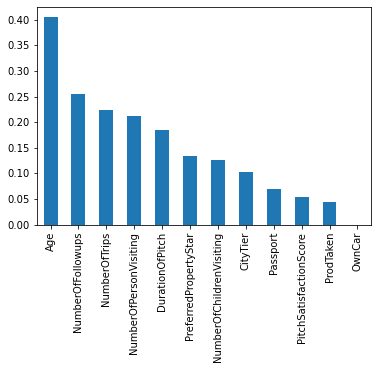

In [41]:
reg.sort_values(ascending = False).plot.bar()

In [43]:
from sklearn.feature_selection import SelectPercentile

In [45]:
sele = SelectPercentile(mutual_info_regression,percentile = 20)
sele.fit(X_train, y_train)
sele.get_support()

array([False,  True, False, False, False,  True, False,  True, False,
       False, False, False])

In [46]:
X_train.columns[sele.get_support()] # This are all the value we need to take.

Index(['Age', 'NumberOfFollowups', 'NumberOfTrips'], dtype='object')